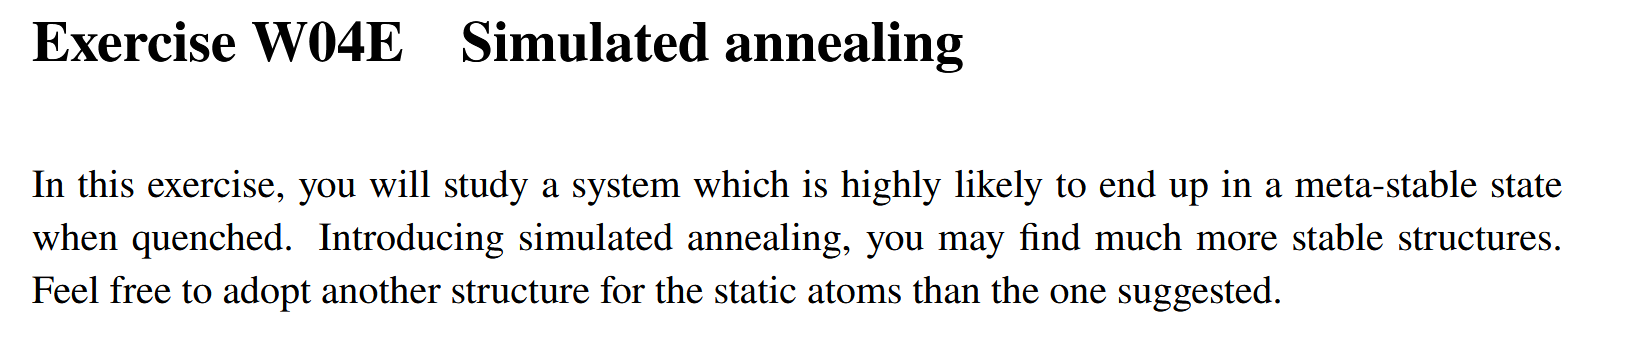

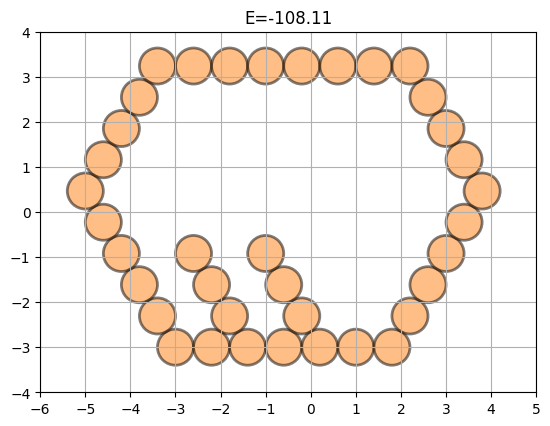

In [5]:
import numpy as np
import matplotlib.pyplot as plt 
from week04 import *

class AtomicCluster(AtomicCluster):
    def __init__(self, *args, title=None, kT=0.15, **kwargs):
        super().__init__(*args, **kwargs)
        self.kT = kT
        self.title = title
        self.v = np.zeros(self.pos.shape)

    @property
    def K(self):
        return 0.5 * np.sum(self.v**2) # assume m=1

    def get_velocity(self):
        return self.v.copy()
    
    def set_velocity(self, v):
        self.v = v

    def draw_title(self, ax):
        ek = self.K
        ep = self.potential_energy
        etot = ek+ep
        ax.set_title(f'E={etot:7.2f}')

morse = Morse() 

def create_initial_cluster(N=5, kT=0.15):
    pos = []
    a = np.array([1, 0]) * 0.8
    b = np.array([0.5, np.sqrt(3)/2]) * 0.8
    
    coords = [(0 ,0) ,(1,0) ,(2,0) ,(3,0) ,(4,0) ,(5,0) ,(6,0),
            (-1,1) ,(1,1) ,(3,1) ,(6,1),
            (-2,2) ,(0,2) ,(2,2) ,(6,2),
            (-3,3) ,(-1,3) ,(1,3) ,(6,3),
            (-4,4) ,(6,4) ,(-5,5) ,(6,5),
            (-5,6) ,(5,6) ,(-5,7) ,(4,7),
            (-5,8) ,(3,8),
            (-5,9) ,(-4,9) ,(-3,9) ,(-2,9) ,(-1,9) ,(0,9) ,(1,9) ,(2,9)]
    
    for (i, j) in coords:
        pos.append(i*a + j*b + np.array([-3, -3]))
    
    Nouter = len(pos)
    Ninner = N
    
    # 2. Add N random coordinates bounded inside the cavity (roughly -1.5 to 1.5)
    random_positions = list(np.random.uniform(-1.5, 1.5, size=(Ninner, 2)))
    pos += random_positions
    
    static = Nouter * [True] + Ninner * [False]
    title = 'Random'
    
    return AtomicCluster(morse, pos=pos, static=static, kT=kT, title=title)

fig, ax = plt.subplots()
frame = create_initial_cluster(N=0)
frame.title = 'Frame'
frame.draw(ax, size=0.4)
nice_plot(ax)
ax.set_xlim(-6,5)
ax.set_ylim(-4, 4)

plt.show()

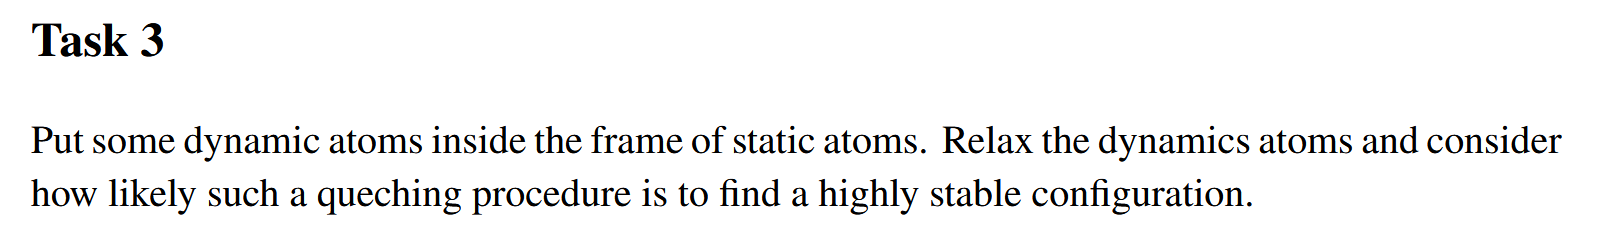

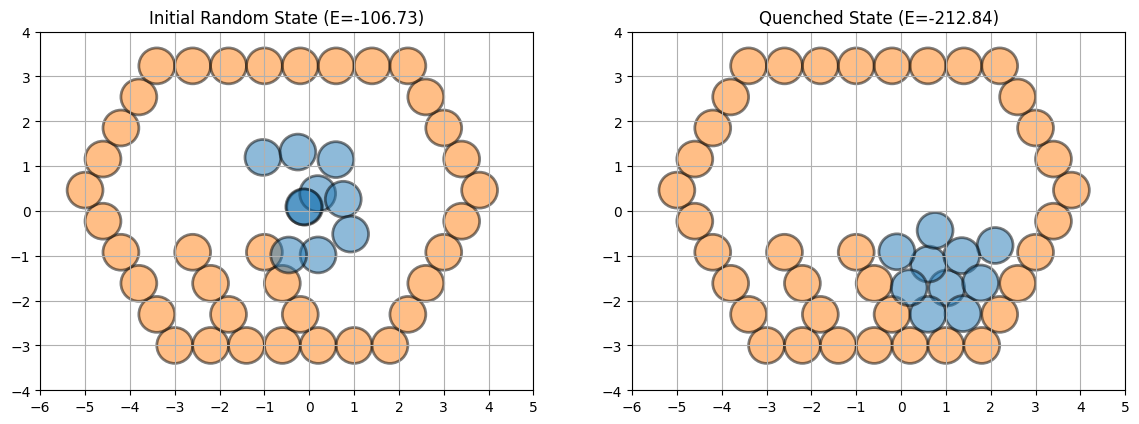

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cluster = create_initial_cluster(N=10) 

cluster.draw(axes[0], size=0.4)
nice_plot(axes[0])
axes[0].set_xlim(-6, 5)
axes[0].set_ylim(-4, 4)
axes[0].set_title(f'Initial Random State (E={cluster.potential_energy:.2f})')

relax(cluster, steps=200) 

cluster.draw(axes[1], size=0.4)
nice_plot(axes[1])
axes[1].set_xlim(-6, 5)
axes[1].set_ylim(-4, 4)
axes[1].set_title(f'Quenched State (E={cluster.potential_energy:.2f})')

plt.show()

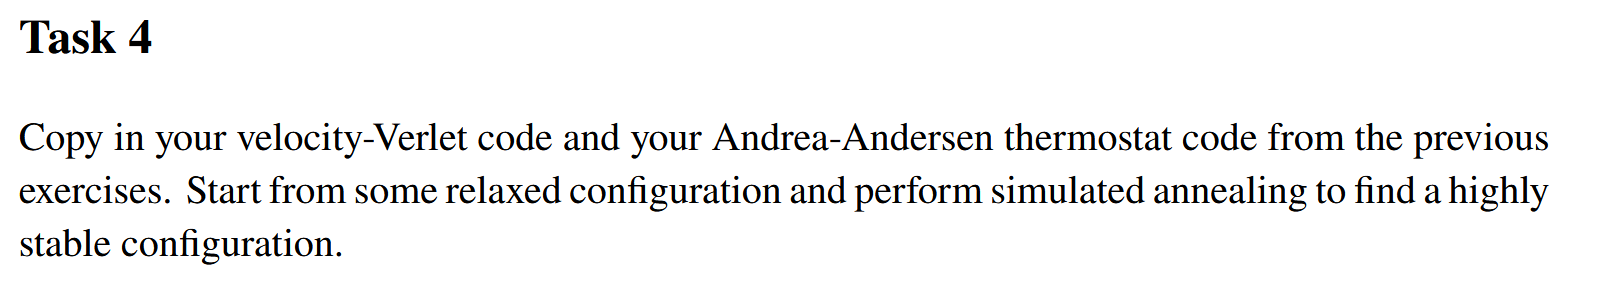

Starting simulated annealing...


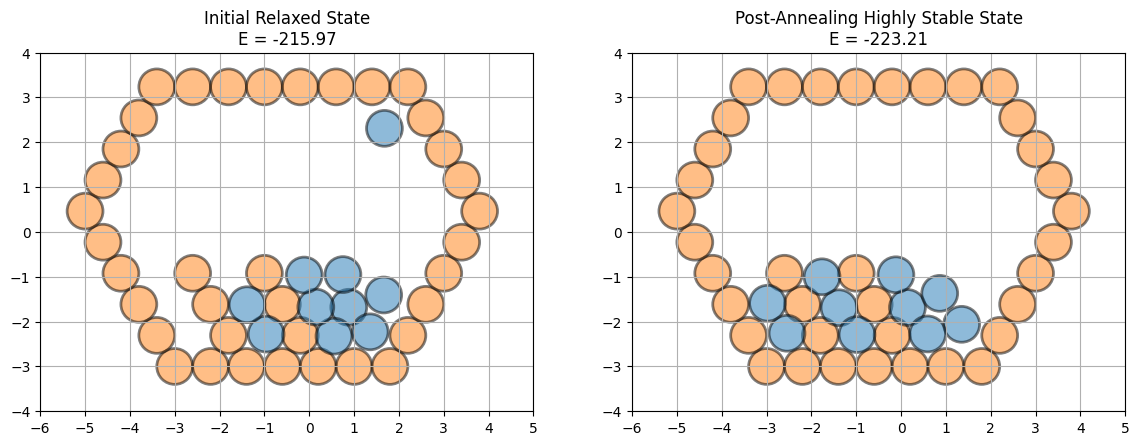

In [ ]:
def thermostat(cluster, kT):
    scale = np.sqrt(kT) # Assume m=1
    v_old = cluster.get_velocity()
    v_new = np.random.normal(0, scale, size=v_old.shape)
    
    # Zero out the velocity for all static atoms
    is_static = np.array(cluster.static)
    v_new[is_static] = 0.0 
    
    cluster.set_velocity(v_new)

def velocity_verlet(cluster, N=100, dt=0.01):
    a_t = cluster.forces # assume m=1
    r = cluster.get_positions()
    v = cluster.get_velocity()
    
    # Pre-calculate the mask for speed
    is_static = np.array(cluster.static)

    for _ in range(N):
        # 2. Prevent static atoms from accelerating
        a_t[is_static] = 0.0 
        v[is_static] = 0.0
        
        r += v*dt + 0.5*a_t*dt**2
        cluster.set_positions(r)

        a_dt = cluster.forces # assume m=1
        
        # 3. Prevent new forces from affecting static atoms
        a_dt[is_static] = 0.0 

        v += 0.5* (a_t + a_dt) * dt

        a_t = a_dt.copy()

    cluster.set_velocity(v)

    e = cluster.potential_energy + cluster.K
    return cluster.get_positions(), e

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cluster = create_initial_cluster(N=10)
relax(cluster, steps=200)

cluster.draw(axes[0], size=0.4)
nice_plot(axes[0])
axes[0].set_xlim(-6, 5)
axes[0].set_ylim(-4, 4)
axes[0].set_title(f'Initial Relaxed State\nE = {cluster.potential_energy:.2f}')

# Simulated Annealing 
for kT in [2.0, 1.0, 0.5, 0.05]:
    for _ in range(50): 
        thermostat(cluster, kT=kT)
        velocity_verlet(cluster, N=50, dt=0.05)

# Relax again
relax(cluster, steps=200)

cluster.draw(axes[1], size=0.4)
nice_plot(axes[1])
axes[1].set_xlim(-6, 5)
axes[1].set_ylim(-4, 4)
axes[1].set_title(f'Post-Annealing Highly Stable State\nE = {cluster.potential_energy:.2f}')

plt.show()